# VolCali alphaMELTS workshop

Welcome to the notebook for the 2026 VolCali alphaMELTS workshop. In this session we'll be getting to grips with 2 of the newer packages, and approaches, that are part of the alphaMELTS 'family': PetThermoTools and nGibbs. PetThermoTools is a Python front-end to the alphaMELTS for Python and MAGEMin packages (Antoshechkina and Ghiorso, 2018; Riel et al. 2022), providing easy access to thermodynamic modeling within a Python environment with built-in functions for the most common thermodyanmic methods. Within this notebook we'll use PetThermoTools to calculate melt inclusion saturation pressures, examine liquidus phase assemblages, calculate potential crystallization paths, and compare phase diagrams for Mauna Loa and Kilauea volcanic systems. nGibbs is a Machine Learning emulator trained on thermodynamic simulations. One version of nGibbs is trained on rhyolite-MELTS v1.0.2 models, and we will use this emulator to demonstrate how ML can be used to provide a significant speed up in "thermodynamic" calculations.

This workshop will only serve as a brief introduction to both PetThermoTools and nGibbs. If you're interested in learning more ask to join our Discord server and/or check out our documentation and examples over on ReadtheDocs (https://petthermotools.readthedocs.io/en/latest/) and YouTube (https://www.youtube.com/@PetThermoTools). Most importantly, we encourage any users that have not yet done so already to check out our installation instructions: https://www.youtube.com/watch?v=-Mz8CIkbi38&t=3s & https://www.youtube.com/watch?v=yHNiX8P7xXw&t=2s

As with any Python based workshop, let's start by importing the main Python libraries into our environment:

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

Let's also import PetThermoTools - if you haven't done so already please install PetThermoTools following the instructions outlined in the videos above - it's also worth checking the version number for PetThermoTools at this point. You should see `v1.0.0` printed when you run the following cell. 

In [6]:
import petthermotools as ptt 
ptt.__version__

alphaMELTS for Python files successfully located.
If using the Green et al. (2025) or Weller et al. (2024) thermodynamic models please run `ptt.activate_petthermotools_env()` prior to any calculations.


'0.4.5'

For most people the previous cell likely printed a message stating 

`alphaMELTS for Python files successfully located.`. 

If instead you see a message that includes

```Use `import sys; sys.path.append(r'path_to_alphaMELTS_4_python')` to add the alphaMELTS for Python files to the Python path.``` 

then you will need to uncomment the two lines below and insert the path to the alphaMELTS for Python files (specifically the folder containing the meltsdynamic.py file) on your machine.

In [ ]:
# import sys
# sys.path.append(f"path_to_meltsdynamic.py")

## Part 1 - Kilauea melt inclusions

For the first part of this workshop we'll be using a dataset of olivine hosted melt inclusions from Kilauea, specifically from the Lower East Rift Zone (LERZ) eruption of 2018. These data were collected by Penny Wieser and the values included here have already been corrected for the influence of post-entrapment crystallization (Wieser et al. 2021; https://doi.org/10.1029/2020GC009364).

![Fig 11 from Wieser et al. 2021](https://agupubs.onlinelibrary.wiley.com/cms/asset/dd37c7dd-25f1-4f01-8976-ffaa3dd019a1/ggge22398-fig-0011-m.jpg)

### 1.1 - Getting up to speed with Python

**Before we get into the thermodynamics, let's first make sure everyone is comfortable with the basics of Python. To start, we'll use Pandas to load in the PEC corrected olivine-hosted melt inclusion compositions from the 2018 eruption**

In [7]:
Kil = pd.read_excel('Kilauea_olivines.xlsx')
Kil.head()

,Label,SiO2,TiO2,Al2O3,FeO,Fe2O3,MnO,MgO,CaO,Na2O,K2O,P2O5,H2O,CO2,Temp,SaturationP_bars_VESIcal,XH2O_fl_VESIcal
0,LLD_LL1_80,51.423,3.229,13.392,9.68660,1.899333,0.149,6.191,9.859,2.636,0.675,0.337,0.533371,0.025772,1138.4391,420,0.132780
1,LLD_LL1_103,51.375,3.343,13.202,10.09460,1.979333,0.134,6.001,9.729,2.602,0.635,0.364,0.546140,0.021389,1134.6201,360,0.160732
2,LLE_LL4_19b,50.793,2.550,13.523,9.63645,1.889500,0.179,7.432,10.594,2.303,0.429,0.378,0.500000,0.040292,1163.3832,640,0.082606
3,LLE_LL4_19c,51.117,2.512,13.435,9.71890,1.905666,0.239,7.526,10.170,2.435,0.382,0.276,0.500000,0.022817,1165.2726,370,0.132469
4,LLE_LL4_33b,51.649,2.758,13.747,9.63730,1.889666,0.282,6.020,10.397,2.435,0.496,0.347,0.500000,0.024655,1135.0020,420,0.115698


**Now let's practice some data handling and basic plotting. First examine the `Label` column in the dataset. You should see some samples which contain the code `LL8` in their Label. These are melt inclusions from lavas erupted in mid-July from what was originally termed 'Fissure 8'. Have a go isolating just these inclusions, creating a new dataframe called `LL8`.**

**Once this is completed, use the code below to create a simple plot of MgO vs CaO for the melt inclusions, with the LL8 samples identifiable through a different color or symbol.**

In [3]:
LL8 = Kil.loc[Kil['Label'].str.contains("LL8")].reset_index(drop = True)

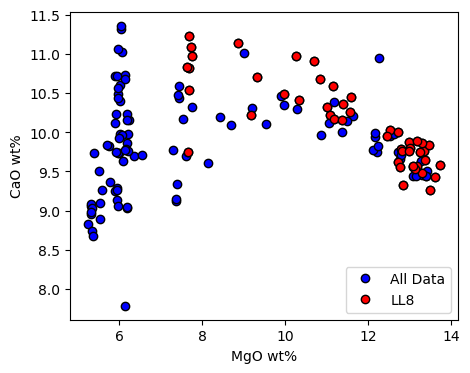

In [5]:
plt.figure(figsize = (5, 4))
plt.plot(Kil['MgO'], Kil['CaO'], 'ok', mfc = 'b', label = "All Data")
plt.plot(LL8['MgO'], LL8['CaO'], 'ok', mfc = 'r', label = "LL8")
plt.xlabel('MgO wt%')
plt.ylabel('CaO wt%')
plt.legend()

### 1.2 - Melt inclusion saturation pressures

Before we go any further I would recommend that all MacOS and Linux users run the following cell **twice**. This suppresses all outputs from the MELTS C code (which overwise all appears in the notebook). This is not an issue for Windows users.

In [7]:
import platform
if platform.system()=="Darwin" or platform.system() == "Linux":
    import sys
    import os
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

PetThermoTools provides you with 2 ways to calculate melt inclusion saturation pressures. Notably, in both methods you need to provide the CO$_2$ contents in wt% (combining the CO$_2$ contribute from both the melt phase and bubble if present).

1. Simple saturation pressure calculations - we can use the rhyolite-MELTS v1.2.0 model (Ghiorso and Gualda, 2015) to calculate saturation pressure assuming a known temperature (`T_fixed_C` - usually determined using an empirical, liquid-based thermometer). All solid phases are turned off for these calculations, allowing the system to only stabilze liquid and fluid phases. The system will then iterate pressure to find the point of volatile saturation for each composition provided. This should be relatively fast. **Run the cell below and examine the structure of the outputs.** This method is essentially the same as that used in VESIcal when the magmasat model is selected (Iacovino et al. 2021).

In [8]:
Sat_P = ptt.saturation_pressure(Model = "MELTSv1.2.0",
                                bulk = LL8,
                                P_init_bar = 1000,
                                T_fixed_C = LL8['Temp'])

Sat_P.head()

Completed 100.0 %


,SiO2_Liq,TiO2_Liq,Al2O3_Liq,FeOt_Liq,MnO_Liq,MgO_Liq,CaO_Liq,Na2O_Liq,K2O_Liq,P2O5_Liq,H2O_Liq,CO2_Liq,Fe3Fet_Liq,P_bar,T_Liq_C
0,50.857554,2.414620,12.845737,11.297028,0.213348,7.642640,11.198771,2.194293,0.402769,0.245250,0.498449,0.000960,0.149892,57.861328,1168.0866
1,51.000035,2.368247,12.836974,11.335442,0.187387,7.702782,11.047831,2.168899,0.403678,0.243204,0.498360,0.017938,0.149892,308.593750,1169.3328
2,51.210784,2.524405,12.968435,11.283730,0.151305,7.646877,10.492806,2.285502,0.500700,0.217999,0.497714,0.031384,0.149892,507.812500,1168.4082
3,50.999298,2.507558,13.008644,11.285065,0.157282,7.648103,10.766872,2.237789,0.432029,0.247869,0.497729,0.023381,0.149892,392.578125,1168.4283
4,49.571081,2.159078,11.980592,11.293353,0.253188,11.037615,10.181360,2.234835,0.338913,0.260166,0.498402,0.002898,0.149892,83.007812,1236.5673


This works well when you simply want the saturation pressure. But what if you intend to run further calculations using these compositions? In that case, its more useful to use PetThermoTools to solve for both pressure and temperature.

2. Coupled saturation pressure and liquidus calculations - one of the advanatages of PetThermoTools compared to VESIcal is the ability to deal with solid-melt-fluid systems, rather than a 2-component melt-fluid system. This means we can provide an initial temperature (`T_init_C`) rather than a fixed temperature and the system with iteratively solve for both T & P, searching for the highest pressure at which volatie saturation occurs at the liquidus temperature. **Complete the cell below to calculate the saturation pressure and liquidus temperature of these melt inclusion compositions. Use the following cells below to plot the two different pressure estimates and two different temperature estimates against each other.**

In [10]:
Sat_PT = ptt.saturation_pressure(Model = "MELTSv1.2.0",
                                bulk = LL8,
                                P_init_bar = 1000,
                                T_init_C = LL8['Temp'] + 50)

Completed 100.0 %


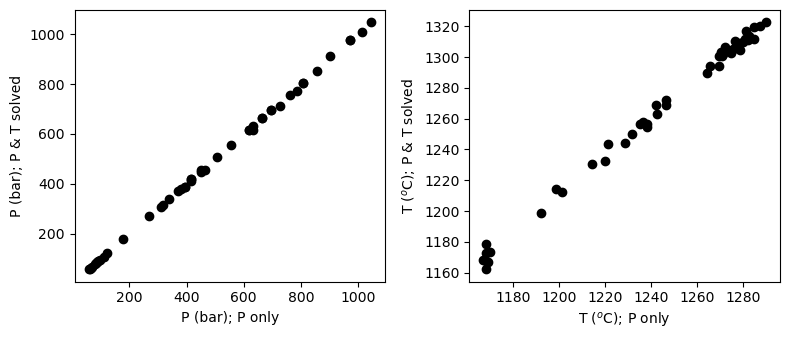

In [10]:
f, a = plt.subplots(1,2, figsize = (8, 3.5))
a[0].plot(Sat_P['P_bar'], Sat_PT['P_bar'], 'ok')
a[0].set_ylabel('P (bar); P & T solved')
a[0].set_xlabel('P (bar); P only')

a[1].plot(Sat_P['T_Liq_C'], Sat_PT['T_Liq_C'], 'ok')
a[1].set_ylabel('T ($^o$C); P & T solved')
a[1].set_xlabel('T ($^o$C); P only')

f.tight_layout()

### 1.3 - Equilibration calculations and output structure

What we can do, now that we have a composition, pressure, and temperature for each inclusion, is run a set of simple equilibration calculations. Given that we searched for the P & T conditions of volatile saturation at the liquidus above, what these calculations will hopefully show is that the system is almost entirely melt/liquid at these conditions with a small about of fluid and a single solid phase. 

**Run the `equilibrate_multi` function below and examine the outputs. Specifically have a look at the `mass_g` DataFrame. What is the liquidus phase for these compositions? Is this expected?**

In [11]:
from time import time

start_time = time()
equil = ptt.equilibrate_multi(Model = "MELTSv1.2.0",
                            bulk = LL8,
                            P_bar = Sat_PT['P_bar'].values,
                            T_C = Sat_PT['T_Liq_C'].values)
end_time = time()
print(f"Equilibration time: {end_time - start_time} seconds")


Completed 17.02127659574468 %
Completed 34.04255319148936 %
Completed 51.06382978723404 %
Completed 68.08510638297872 %
Completed 85.1063829787234 %
Completed 100.0 %
Equilibration time: 58.89723801612854 seconds


In [37]:
for col, val in LL8.items():
    print(f"{col}: {val}")

Label: 0     LLF_LL8_249a
1     LLf_LL8_249b
2     LLf_LL8_249c
3     LLf_LL8_249d
4     LLG_LL8_402a
5     LLg_LL8_402b
6      LLG_LL8_447
7     LLg_LL8_3001
8          LL8_435
9         LL8_613b
10         LL8_615
11       LL8_617_a
12       LL8_623_b
13       LL8_623_c
14         LL8_626
15       LL8_404_a
16       LL8_404_b
17         LL8_610
18       LL8_612_a
19       LL8_612_b
20       LL8_613_a
21       LL8_617_b
22         LL8_624
23         LL8_630
24        LL8_631a
25       LL8_616_b
26       LL8_202_c
27       LL8_243_b
28         LL8_156
29        LL8_155b
30         LL8_406
31         LL8_302
32         LL8_611
33       LL8_616_a
34         LL8_634
35         LL8_606
36       LL8_202_a
37       LL8_202_b
38         LL8_426
39         LL8_401
40       LL8_400_b
41       LL8_400_a
42         LL8_280
43        LL8_300R
44         LL8_232
45       LL8_155_c
46         LL8_301
Name: Label, dtype: object
SiO2: 0     51.013
1     51.167
2     51.446
3     51.232
4     49.730
5 

In [23]:
equil['Conditions']

,T_C,P_bar,mass_g,H_J,S_J/K,V_cm^3,rho_kg/m^3,log10(fO2),dVdP_cm^3/bar
0,1162.106274,58.0,100.0,-1.205765e+06,266.930288,37.413404,2672.838887,-8.831853,-0.000215
1,1166.830451,309.0,100.0,-1.204571e+06,267.356694,37.395702,2674.104067,-8.728250,-0.000216
2,1172.814946,508.0,100.0,-1.203613e+06,268.200979,37.454003,2669.941575,-8.608657,-0.000219
3,1167.803792,387.0,100.0,-1.204828e+06,267.578395,37.415069,2672.719938,-8.692366,-0.000217
4,1257.737150,83.0,100.0,-1.193552e+06,277.541584,37.352213,2677.217531,-7.598609,-0.000206
5,1256.293392,91.0,100.0,-1.193521e+06,277.468644,37.390671,2674.463899,-7.643286,-0.000205
6,1256.669529,122.0,100.0,-1.193698e+06,277.158348,37.253365,2684.321286,-7.571595,-0.000204
7,1198.419699,270.0,100.0,-1.200323e+06,271.071413,37.268807,2683.209031,-8.333934,-0.000210
8,1214.459285,316.0,100.0,-1.196890e+06,273.068997,37.335053,2678.448086,-8.086604,-0.000213
9,1212.479210,340.0,100.0,-1.198419e+06,272.899089,37.309336,2680.294280,-8.148134,-0.000209


In [ ]:
start_time = time()
nGibbs_equil = ptt.equilibrate_multi(Model = "nMELTSv1.2.0NoProp",
                            bulk = LL8,
                            P_bar = Sat_PT['P_bar'].values,
                            T_C = Sat_PT['T_Liq_C'].values)
end_time = time()
print(f"nGibbs Equilibration time: {end_time - start_time} seconds")

In [10]:
equil['mass_g']

,olivine1,liquid1,fluid1
0,0.038288,99.961712,0.000000
1,0.023659,99.976194,0.000147
2,0.030048,99.969848,0.000104
3,0.086624,99.913376,0.000000
4,0.038792,99.961138,0.000069
5,0.072332,99.927622,0.000045
6,0.058097,99.941903,0.000000
7,0.000916,99.998981,0.000104
8,0.041135,99.958696,0.000169
9,0.079174,99.920826,0.000000


## Part 2 - Crystallization calculations

### 2.1 - extracting a starting composition

Now we've got the hang of how PetThermoTools works, and how the output structures are designed, let's have a go running some crystallization calculations. The first thing to do is identify a suitable starting composition. **Isolate the row in the `Kil` DataFrame corresponding to the highest MgO content melt inclusion and use the `.squeeze()` method to turn this into a Pandas Series.**

In [30]:
Kil_starting = Kil.loc[Kil['MgO'] == Kil['MgO'].max()].squeeze()

In [32]:
Kil_starting.labels

AttributeError: 'Series' object has no attribute 'labels'

Before we go any further let's also load in some matrix glass data from the 2018 Kilauea eruption (again from Wieser et al. 2021).

In [26]:
Kil_glass = pd.read_excel("Kilauea_glass.xlsx")
Kil_glass.head()

,Description,Sample Name,Fissure (eruption date),Na2O,Al2O3,P2O5,CaO,K2O,TiO2,SiO2,MgO,FeOt,MnO
0,NaN,LLE_LL4_G2,Fissure 8 (May 30th),2.5120,13.0360,0.2689,10.2471,0.5234,2.8773,50.6243,5.8471,11.8288,0.1830
1,NaN,LLE_LL4_G1,Fissure 8 (May 30th),2.4681,12.8885,0.2652,9.9658,0.5305,2.8840,50.0975,5.8521,11.2897,0.1769
2,NaN,LLf_LL8_g2,Fissure 8 (Mid July),2.2884,13.0277,0.2068,10.6820,0.4462,2.5827,50.1517,6.6763,11.2420,0.2141
3,NaN,LLf_LL8_g1,Fissure 8 (Mid July),2.3660,13.1034,0.2329,10.7276,0.4822,2.5686,50.2523,6.4934,10.9155,0.1948
4,NaN,LLf_LL7_G2,Fissure 8 (Aug 1st),2.4155,13.2432,0.2393,10.6298,0.4704,2.6104,51.1145,6.5764,11.1522,0.1738


### 2.2 - Isobaric crystallization

Likely the most common function used in PetThermoTools is the `isobaric_crystallisation` function (note that it is an 's' not a 'z' because I'm British). So let's learn how to use that!

There are many options in the `isobaric_crystallization` function. We need to provide information about pressure (`P_bar`), the starting composition (`bulk`) and the thermodynamic model (`Model`). In addition, we need to specify temperature constraints, information about the oxygen fugacity of the system, and whether we wish to perform fractional or equilibrium crystallization. There are many other options, which you can learn about through our documentation.

**Using the code below perform 4 equilibrium crystallization calculations at different pressures. Try running similar calculations using fractional crystallization instead.**

In [1]:
isobaric = ptt.isobaric_crystallisation(Model = "MELTSv1.0.2",
                                        bulk = Kil_starting,
                                        P_bar = [250,500,1000,2000],
                                        find_liquidus = True,
                                        T_end_C = 1050,
                                        dt_C = 2,
                                        label = "P_bar")

NameError: name 'ptt' is not defined

Use the cell below to examine the outputs (hint use `isobaric.keys()` to see how the different calculations are stored in the output dictionary). 

**Use the `ptt.harker()` function to plot the results. We can also plot the matrix glass data from Wieser et al. (2021) using this function. Are these calculations doing a good job? If you're waiting, try different H2O or fO2 settings, and/or try different thermodynamic models.**

(<Figure size 960x900 with 9 Axes>,
 array([[<Axes: xlabel='MgO', ylabel='SiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='TiO$_2$'>,
         <Axes: xlabel='MgO', ylabel='Al$_2$O$_3$'>],
        [<Axes: xlabel='MgO', ylabel='FeO$_t$'>,
         <Axes: xlabel='MgO', ylabel='CaO'>,
         <Axes: xlabel='MgO', ylabel='Na$_2$O'>],
        [<Axes: xlabel='MgO', ylabel='K$_2$O'>, <Axes: >, <Axes: >]],
       dtype=object))

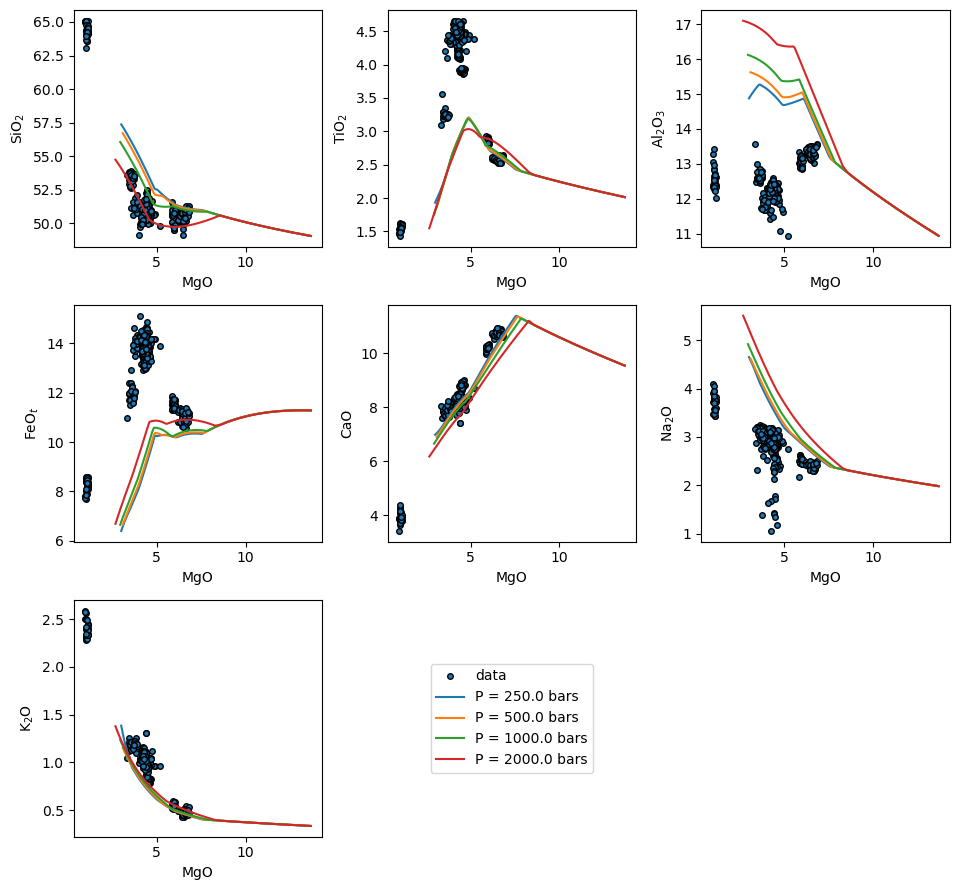

In [27]:
ptt.harker(Results = isobaric, data = Kil_glass)

## Part 3 - Phase Diagrams

One interesting observation from the Hawaiian islands is that high-MgO orthopyroxene crystals are sometimes observed in lavas from the Loa trend (Mauna Loa, Hualalai, etc.) but these are rare or completely absent in samples from the Kea trend (Kilauea, Mauna Kea, Haleakala, etc.). The question becomes, is this something we can predict through thermodynamics, given that there are subtle differences in the major element composition of primary melts from each trend (see Fig. 8a in Wieser et al. 2025 for more details; https://doi.org/10.1007/s00445-025-01869-2).

**Using the Kilauea starting composition we defined earlier calculate and plot the phase diagram for this composition at pressures between 250 and 5000 bar and temperatures between 1100 and 1400 Celsius (hint, use `np.linspace`)**

In [13]:
PD_Kil = ptt.phaseDiagram_calc(Model = "MELTSv1.0.2",
                                bulk = Kil_starting,
                                T_C = np.linspace(1100,1400,20),
                                P_bar = np.linspace(250,5000,20),
                                refine = 2,
                                i_max = 10)

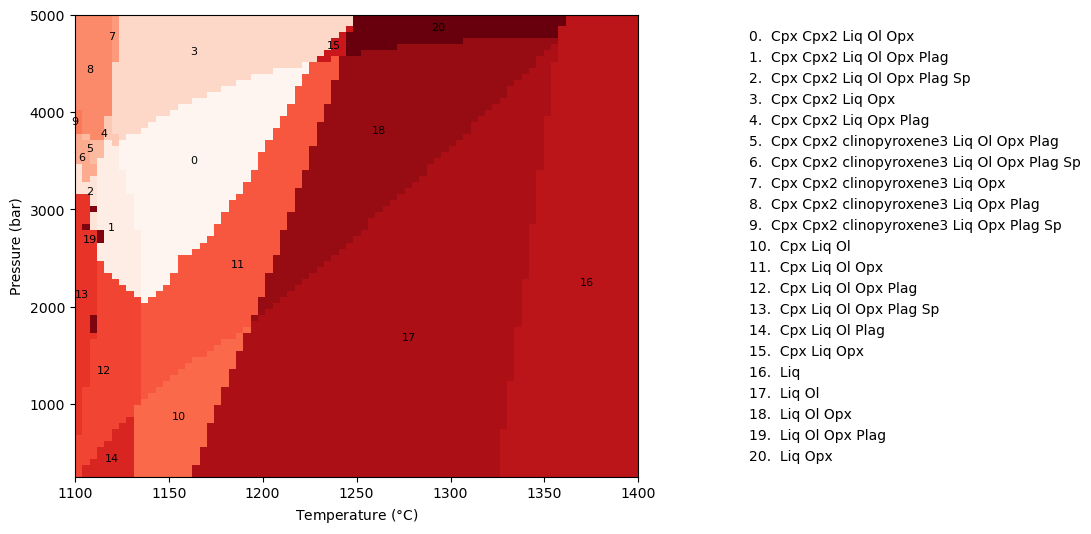

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: xlabel='Temperature ($\\degree$C)', ylabel='Pressure (bar)'>,
        <Axes: >], dtype=object))

In [14]:
ptt.plot_phaseDiagram(Combined = PD_Kil)

**Do the same calculation using this primary melt composition from Mauna Loa from Wieser et al. (2025). Do you notice any differences in the pressure and temperature of orthopyroxene stability?**

In [15]:
# Mauna Loa estimated primary melt composition from Wieser et al. 2025
ML_starting = {
    'SiO2_Liq': 48.5858,
    'TiO2_Liq': 1.4381,
    'Al2O3_Liq': 9.73,
    'FeOt_Liq': 10.144,        
    'MgO_Liq': 20.0,
    'CaO_Liq': 7.2186,
    'Na2O_Liq': 1.7327,
    'K2O_Liq': 0.3227,
    'Cr2O3_Liq': 0.0702,
    'H2O_Liq': 0.2,
    'Fe3Fet_Liq': 0.12       
}

In [16]:
PD_ML = ptt.phaseDiagram_calc(Model = "MELTSv1.0.2",
                                bulk = ML_starting,
                                T_C = np.linspace(1100,1400,20),
                                P_bar = np.linspace(250,5000,20),
                                refine = 2,
                                i_max = 10)

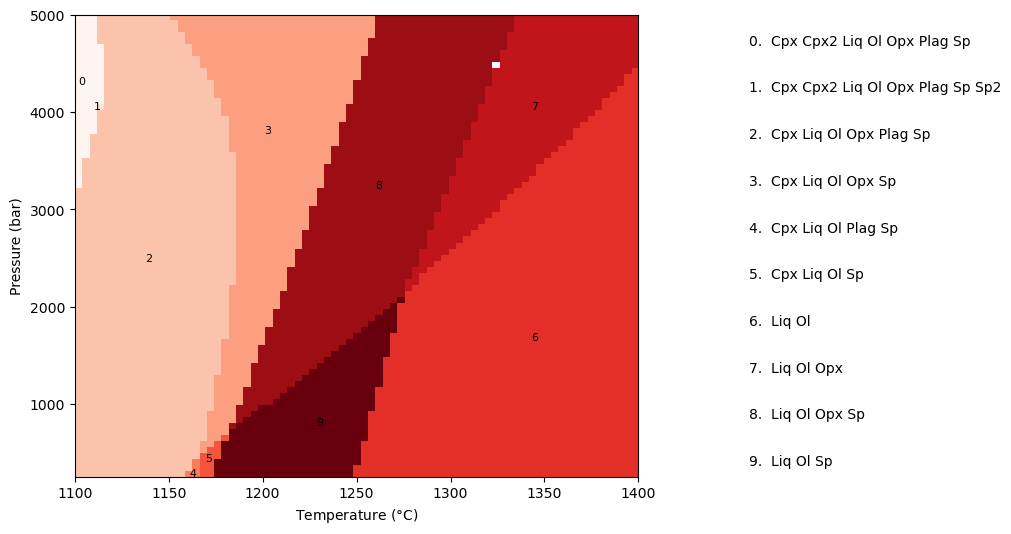

(<Figure size 1000x600 with 2 Axes>,
 array([<Axes: xlabel='Temperature ($\\degree$C)', ylabel='Pressure (bar)'>,
        <Axes: >], dtype=object))

In [17]:
ptt.plot_phaseDiagram(Combined = PD_ML)

(<Figure size 1000x1000 with 3 Axes>,
 [<Axes: title={'center': 'Kilauea'}, xlabel='Temperature ($\\degree$C)', ylabel='Pressure (bar)'>,
  <Axes: title={'center': 'Mauna Loa'}, xlabel='Temperature ($\\degree$C)', ylabel='Pressure (bar)'>,
  <Axes: >])

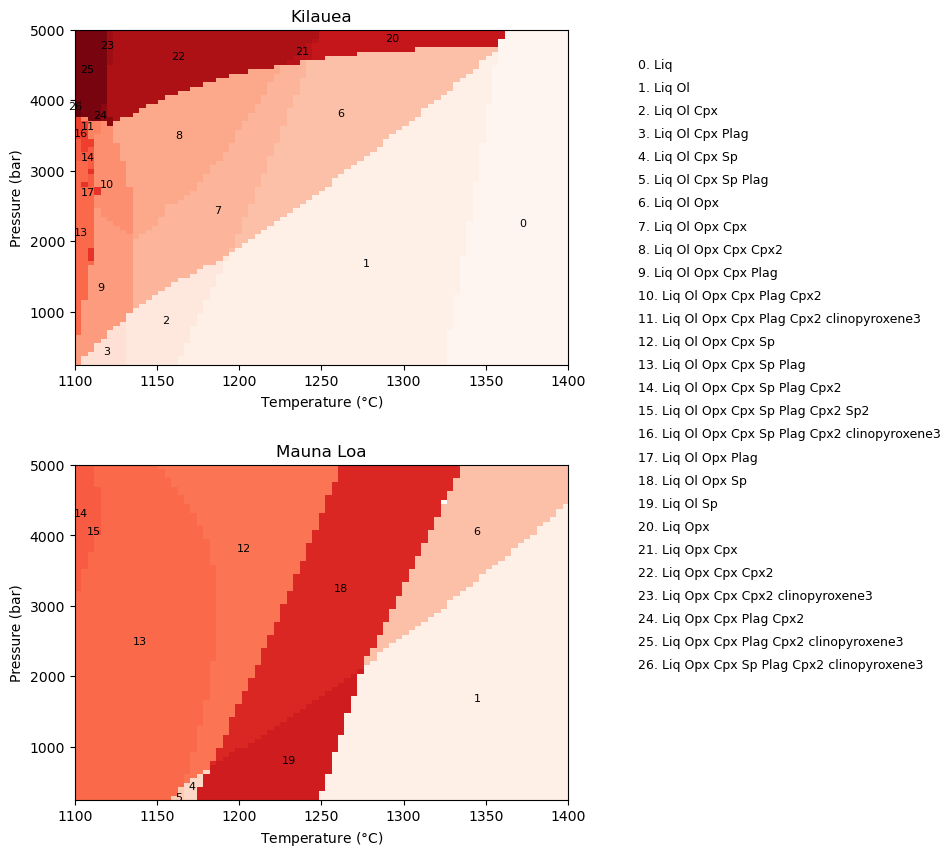

In [30]:
ptt.plot_phaseDiagram_multi({"Kilauea": PD_Kil, "Mauna Loa": PD_ML})

Finally, we can use the following code to extract information from the phase diagrams. In this case let's look directly at the mass of orthopyroxene in each calculation:

In [33]:
X_Kil, Y_Kil, Z_Kil = ptt.make_grid_variables_from_phase_diagram(
    Results = PD_Kil,
    x_col = "T_C",
    y_col = "P_bar",
)

X_ML, Y_ML, Z_ML = ptt.make_grid_variables_from_phase_diagram(
    Results = PD_ML,
    x_col = "T_C",
    y_col = "P_bar",
)

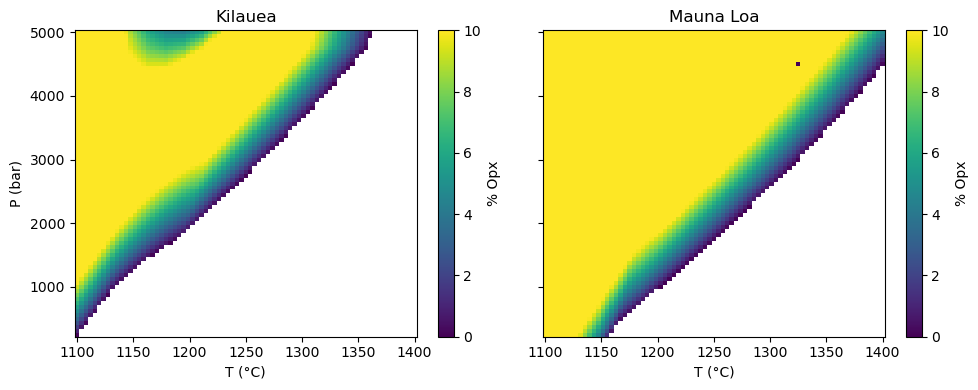

In [48]:
f, a = plt.subplots(
    1, 2, figsize=(10, 4), sharex=True, sharey=True
)

# ------------------------------------------------
# Panel 1: Opx in Kilauea
pcm1 = a[0].pcolormesh(
    X_Kil, Y_Kil, Z_Kil["mass_g_Opx"],
    shading="auto",
    cmap="viridis", vmin=0, vmax=10,
)
a[0].set_title("Kilauea")
a[0].set_xlabel("T (°C)")
a[0].set_ylabel("P (bar)")
f.colorbar(pcm1, ax=a[0], label="% Opx")

# ------------------------------------------------
# Panel 2: Opx in Mauna Loa

pcm2 = a[1].pcolormesh(
    X_ML, Y_ML, Z_ML["mass_g_Opx"],
    shading="auto",
    cmap="viridis", vmin=0, vmax=10,
)
a[1].set_title("Mauna Loa")
a[1].set_xlabel("T (°C)")
f.colorbar(pcm2, ax=a[1], label="% Opx")

f.tight_layout()